In [5]:
import numpy as np
import math as math
import matplotlib.pyplot as plt

# Mass calculations with array of measured diameters
This is the same process as above but I use an array of radii that I measured manually and Isabelle verified with code.

In [3]:
##Now to do mass calculations. D=m/v so Density*Volume = Mass
density_ethanol = 789 ##units are kg/m^3

In [4]:
##tryna see if i can do the above with an array of radii
##these diameters are real measurements that Isabelle did with her code. they very closely match my manual measurements. 
##These diameters are recorded in notion at this link: https://www.notion.so/moorelab/30-June-222c5d00acc280e19045c09c4efb826d

diameter_microns_measured=np.array([49.866493,52.0346,54.92541,52.0346,54.20271,53.118656,52.0346,52.0346,49.866493,54.20271,53.84136,54.20271,53.84136,53.118356])

##diameter to radii
radius_microns_measured= (diameter_microns_measured)/2 

##volume in cubic microns
drop_volume_cubic_microns_measured= 4/3*math.pi*(radius_microns_measured)**3 

##volume converted to cubic meters
drop_volume_cubic_meters_measured=drop_volume_cubic_microns_measured/(1*10**18) 

##mass in kg
drop_mass_kg_measured = density_ethanol * drop_volume_cubic_meters_measured 
print('Drop mass in kilograms', drop_mass_kg_measured)

##converts kg mass to ng
drop_mass_ng_measured = drop_mass_kg_measured * (1*10**12)  
print('Drop mass in nanograms', drop_mass_ng_measured)


Drop mass in kilograms [5.12273753e-11 5.82039269e-11 6.84534826e-11 5.82039269e-11
 6.57867797e-11 6.19179914e-11 5.82039269e-11 5.82039269e-11
 5.12273753e-11 6.57867797e-11 6.44798012e-11 6.57867797e-11
 6.44798012e-11 6.19169423e-11]
Drop mass in nanograms [51.22737526 58.20392692 68.4534826  58.20392692 65.78677966 61.91799142
 58.20392692 58.20392692 51.22737526 65.78677966 64.47980117 65.78677966
 64.47980117 61.91694234]


In [5]:
##converting radius_microns_measured from microns to meters
radius_meters_measured = radius_microns_measured/(1*10**6)
print(radius_meters_measured, ' Radius in meters')

[2.49332465e-05 2.60173000e-05 2.74627050e-05 2.60173000e-05
 2.71013550e-05 2.65593280e-05 2.60173000e-05 2.60173000e-05
 2.49332465e-05 2.71013550e-05 2.69206800e-05 2.71013550e-05
 2.69206800e-05 2.65591780e-05]  Radius in meters


# Charge Calculations with measured diameters, approximating as a conducting sphere where V_electrospray = 3kV
Below I do a several charge calculations using an electrospray voltage of 3kV and measured diameters

In [7]:
##Now onto charge calculations
##If we are approximating to a conducting sphere, then V*4*pi*eplison*r=Q

epsilon = 8.854*10**-12 ##Epsilon is the permitivity of free space with units of F/m
es_voltage =3000 #Voltages applied onto inkjet/electrospray

Q_ES_C= es_voltage*4*math.pi*epsilon*radius_meters_measured #Coulombs
print(Q_ES_C, 'Coulombs')

print(max(Q_ES_C))

##convert from Coulombs to elementary charges
elementary_charges_ES = Q_ES_C*(6.242*10**18)
print(elementary_charges_ES, 'elementary charges')

[8.32241689e-12 8.68426087e-12 9.16671963e-12 8.68426087e-12
 9.04610536e-12 8.86518328e-12 8.68426087e-12 8.68426087e-12
 8.32241689e-12 9.04610536e-12 8.98579822e-12 9.04610536e-12
 8.98579822e-12 8.86513321e-12] Coulombs
9.166719626028964e-12
[51948526.24899085 54207156.37563964 57218663.9056728  54207156.37563964
 56465789.62754489 55336474.04334442 54207156.37563964 54207156.37563964
 51948526.24899085 56465789.62754489 56089352.48848092 56465789.62754489
 56089352.48848092 55336161.51769969] elementary charges


# Q/m, approximating as conducting sphere, with range of measured diameters, Elecrtrospray voltage of 3kV
The below finds a Q/m max of 0.16246034 and a Q/m min of 0.1339116620265269 by varying measured diameters from 49-53 um, but keeps voltage constant at 3kV. 

In [9]:
#charge to mass ratio using charges from varying ES voltages and measured diameters of 49-53um

print(drop_mass_kg_measured, 'kg') ##should be a list

Q_m=Q_ES_C/drop_mass_kg_measured ##this is a list bc i vary the diameter
print(Q_m, 'C/kg approximating drop as a conducting sphere')

print('Q/m maximum', max(Q_m) , 'C/kg')
print('Q/m minimum', min(Q_m), 'C/kg')

[5.12273753e-11 5.82039269e-11 6.84534826e-11 5.82039269e-11
 6.57867797e-11 6.19179914e-11 5.82039269e-11 5.82039269e-11
 5.12273753e-11 6.57867797e-11 6.44798012e-11 6.57867797e-11
 6.44798012e-11 6.19169423e-11] kg
[0.16246034 0.14920404 0.13391166 0.14920404 0.13750643 0.14317621
 0.14920404 0.14920404 0.16246034 0.13750643 0.13935834 0.13750643
 0.13935834 0.14317783] C/kg approximating drop as a conducting sphere
Q/m maximum 0.16246034177881538 C/kg
Q/m minimum 0.1339116620265269 C/kg


# Stability region for a 1.2 mm trap radius given Q/m above

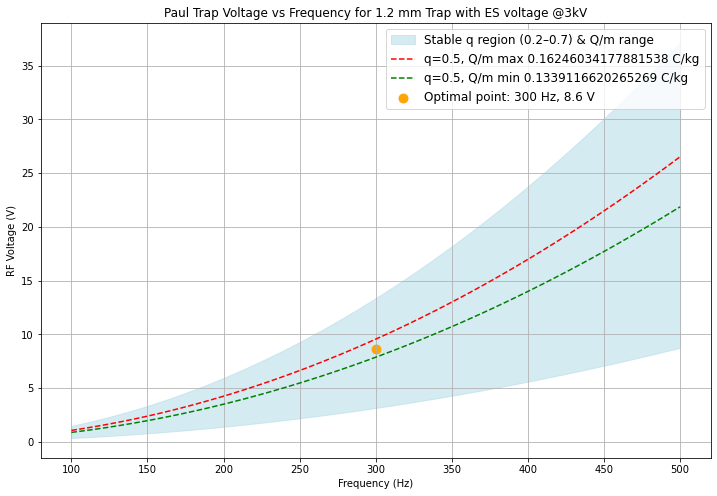

In [11]:

## Parameters 
r0 = 1.2e-3  # Trap radius (m)
f = np.linspace(100,500)  # Frequencies in Hz

## Droplet Q/m measured diameter range of 49-53 µm ethanol drops

Q_m_min = 0.1339116620265269  # C/kg
Q_m_max = 0.16246034177881538  # C/kg


## Stability parameter q 
q_low = 0.2
q_nom = 0.5
q_high = 0.7

## RF voltage calculation
def V_RF(Q_m, q, f):
    return (q * r0**2 * (2 * np.pi * f)**2) / (2 * Q_m)

## Voltages for full stability envelope
V_low = V_RF(Q_m_max, q_low, f)
V_high = V_RF(Q_m_min, q_high, f)

##  Voltages for nominal q lines
V_nom_min = V_RF(Q_m_min, q_nom, f)
V_nom_max = V_RF(Q_m_max, q_nom, f)

## Optimal operating point
f_opt = 300  # Hz
Q_m_opt = (Q_m_min + Q_m_max)/2  # midpoint Q/m
q_opt = 0.5
V_opt = V_RF(Q_m_opt, q_opt, f_opt)

plt.figure(figsize=(12,8))
plt.fill_between(f, V_low, V_high, color='lightblue', alpha=0.5, label='Stable q region (0.2–0.7) & Q/m range')
plt.plot(f, V_nom_min, 'r--', label='q=0.5, Q/m max 0.16246034177881538 C/kg')
plt.plot(f, V_nom_max, 'g--', label='q=0.5, Q/m min 0.1339116620265269 C/kg')


#plt.scatter(PT_volts_list,PT_freq_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')

plt.scatter(f_opt, V_opt, color='orange', s=80, label=f'Optimal point: {f_opt} Hz, {V_opt:.1f} V')
plt.xlabel('Frequency (Hz)')
plt.ylabel('RF Voltage (V)')
#plt.ylim((0,60))
plt.title('Paul Trap Voltage vs Frequency for 1.2 mm Trap with ES voltage @3kV')

plt.rcParams.update({'font.size': 12})
plt.legend()
plt.grid(True)
plt.show()


In [12]:
## ganna try to make an array of previous freq & RF voltages that I have been able to trap at in my old PT 
##so i can see where they lie in terms of theory

### 1Khz, 400V 
#130 Hz, 300V, 
#160Hz, 300V   
#155Hz, 300V
#300Hz, 300V
PT_freq_list = np.array([130, 155, 160, 300])
PT_volts_list = np.array([300, 300, 300, 300])

# Trap stability region for my 4.4mm trap radius, given ES_voltage = 3kV

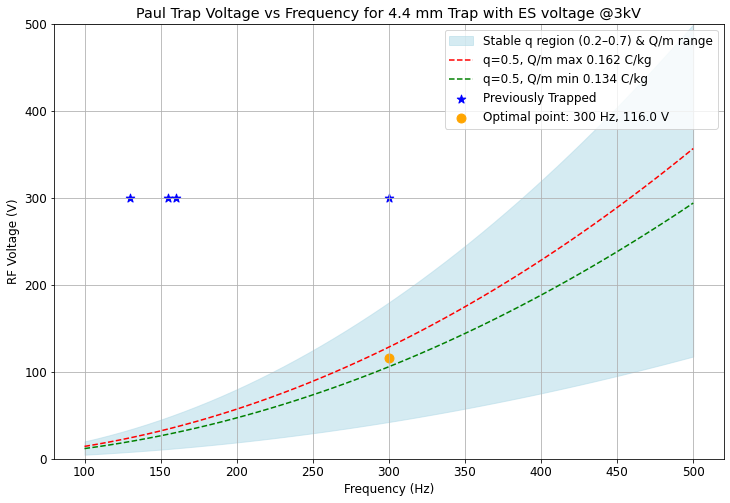

In [14]:

## Parameters 
r0 = 4.4e-3  # Trap radius (m)
f = np.linspace(100,500)  # Frequencies in Hz

## Droplet Q/m measured diameter range of 49-53 µm ethanol drops

Q_m_min = 0.1339116620265269  # C/kg
Q_m_max = 0.16246034177881538  # C/kg


## Stability parameter q 
q_low = 0.2
q_nom = 0.5
q_high = 0.7

## RF voltage calculation
def V_RF(Q_m, q, f):
    return (q * r0**2 * (2 * np.pi * f)**2) / (2 * Q_m)

## Voltages for full stability envelope
V_low = V_RF(Q_m_max, q_low, f)
V_high = V_RF(Q_m_min, q_high, f)

##  Voltages for nominal q lines
V_nom_min = V_RF(Q_m_min, q_nom, f)
V_nom_max = V_RF(Q_m_max, q_nom, f)

## Optimal operating point
f_opt = 300  # Hz
Q_m_opt = (Q_m_min + Q_m_max)/2  # midpoint Q/m
q_opt = 0.5
V_opt = V_RF(Q_m_opt, q_opt, f_opt)

plt.figure(figsize=(12,8))
plt.fill_between(f, V_low, V_high, color='lightblue', alpha=0.5, label='Stable q region (0.2–0.7) & Q/m range')
plt.plot(f, V_nom_min, 'r--', label='q=0.5, Q/m max 0.162 C/kg')
plt.plot(f, V_nom_max, 'g--', label='q=0.5, Q/m min 0.134 C/kg')


plt.scatter(PT_freq_list,PT_volts_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')

plt.scatter(f_opt, V_opt, color='orange', s=80, label=f'Optimal point: {f_opt} Hz, {V_opt:.1f} V')
plt.xlabel('Frequency (Hz)')
plt.ylabel('RF Voltage (V)')
plt.ylim((0,500))
plt.title('Paul Trap Voltage vs Frequency for 4.4 mm Trap with ES voltage @3kV')

plt.rcParams.update({'font.size': 12})
plt.legend()
plt.grid(True)
plt.show()


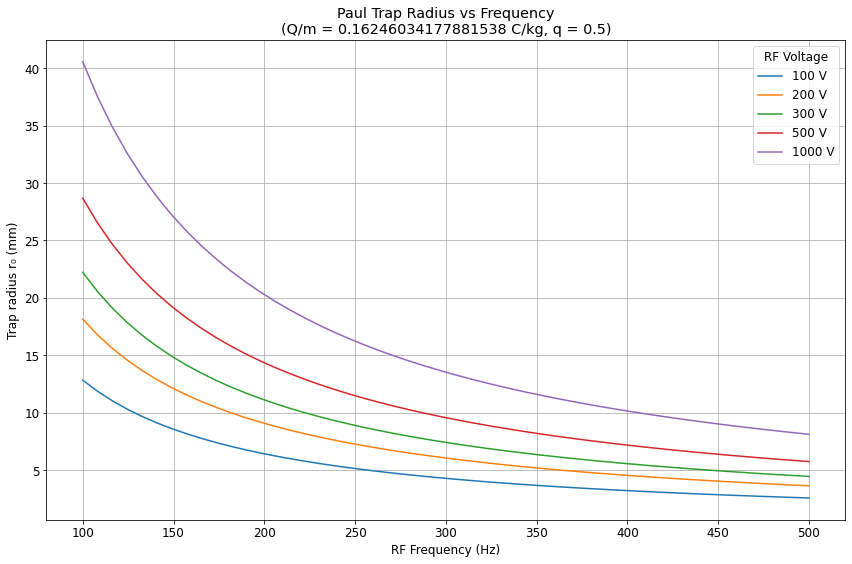

In [15]:
# Fixed parameters
Q_m_max = 0.16246034177881538 # C/kg 
q = 0.5     # Mathieu stability parameter (typical)
freq = np.linspace(100, 500)  # Hz

# RF voltages to compare
voltages = [100, 200, 300, 500, 1000]  # # RF Drive voltage (aka voltage on the rods)


# Trap radius formula is  r0 = sqrt( 2(Q/m)V / ( q (2πf)^2 ) )
def trap_radius(V, f):
    return np.sqrt((2 * Q_m_max * V) / (q * (2*np.pi*f)**2))

plt.figure(figsize=(12,8))

for V in voltages:
    r0 = trap_radius(V, freq)
    plt.plot(freq, r0*1e3, label=f"{V} V")  # convert to mm

plt_2 = plt
plt.xlabel("RF Frequency (Hz)")
plt.ylabel("Trap radius r₀ (mm)")
plt.title("Paul Trap Radius vs Frequency\n(Q/m = 0.16246034177881538 C/kg, q = 0.5)")
plt.grid(True)
plt.legend(title="RF Voltage")

plt.tight_layout()
#plt.show()


# Radius Vs Freq given min and max Q/m at ES_voltage = 3kV

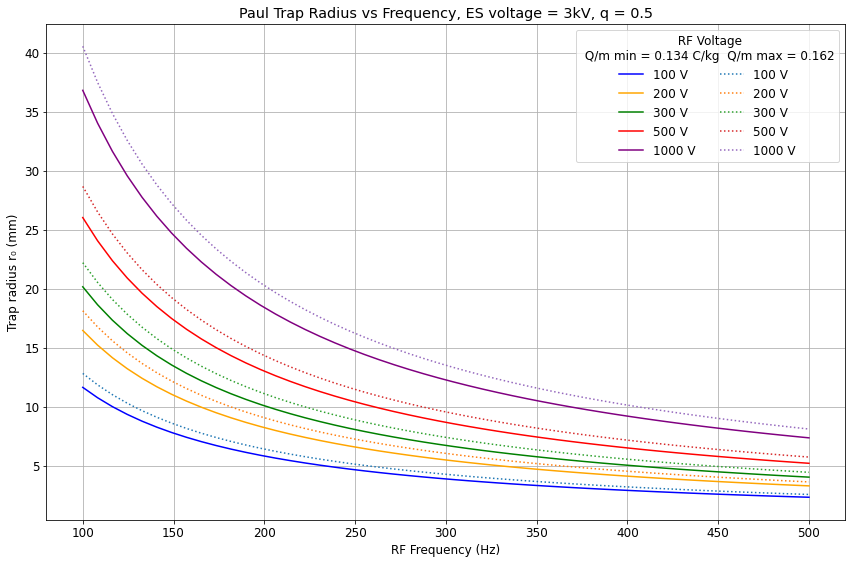

In [17]:
## Fixed parameters
Q_m_min = 0.1339116620265269 # C/kg 
q = 0.5     # Mathieu stability parameter (typical)
freq = np.linspace(100, 500)  # Hz

## RF voltages to compare
voltages = [100, 200, 300, 500, 1000]  # RF Drive voltage (aka voltage on the rods)
colors = ['blue','orange','green', 'red', 'purple'] 


## Trap radius formula is  r0 = sqrt( 2(Q/m)V / ( q (2πf)^2 ) )
def trap_radius(V, f):
    return np.sqrt((2 * Q_m_min * V) / (q * (2*np.pi*f)**2))

plt.figure(figsize=(12,8))

for i in range(0,5):
    V = voltages[i]
    r0 = trap_radius(V, freq)
    plt.plot(freq, r0*1e3, label=f"{V} V",color=colors[i])  # convert to mm


#second plots
Q_m_max = 0.16246034177881538 # C/kg 

# Trap radius formula is  r0 = sqrt( 2(Q/m)V / ( q (2πf)^2 ) )
def trap_radius(V, f):
    return np.sqrt((2 * Q_m_max * V) / (q * (2*np.pi*f)**2))

for V in voltages:
    r0 = trap_radius(V, freq)
    plt.plot(freq, r0*1e3, label=f"{V} V", alpha =1 , linestyle = 'dotted')  # convert to mm


plt.xlabel("RF Frequency (Hz)")
plt.ylabel("Trap radius r₀ (mm)")
plt.title("Paul Trap Radius vs Frequency, ES voltage = 3kV, q = 0.5")
plt.grid(True)
plt.legend(title='                         RF Voltage \n Q/m min = 0.134 C/kg  Q/m max = 0.162', ncol=2)

plt.tight_layout()
plt.show()
plt_2.show()

# Paul Trap design map given min and max Q/m at Electrospray_voltage = 3kV

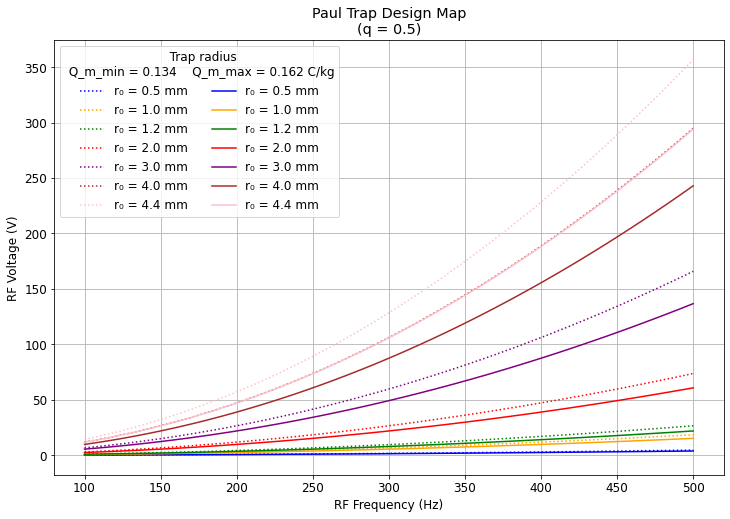

In [19]:

# Fixed parameters
Q_m_min = 0.1339116620265269 # C/kg 
Q_m_max = 0.16246034177881538 
q = 0.5             # Mathieu parameter (typical stable value)

# Frequency range
f = np.linspace(100, 500)  # Hz

plt.figure(figsize=(12,8))

# Trap radii to plot (in mm) to compare
radii_mm = [0.5, 1.0, 1.2, 2.0, 3.0, 4.0, 4.4]
colors = ['blue','orange','green', 'red', 'purple', 'brown', 'pink'] 

# Convert to meters
radii = [r*1e-3 for r in radii_mm]

# Voltage formula:
# V = q * r0^2 * (2πf)^2 / (2 * Q/m)

def V_RF(r0, f):
    return (q * r0**2 * (2*np.pi*f)**2) / (2 * Q_m_min)


i=0
for r0, rmm in zip(radii, radii_mm):
    V = V_RF(r0, f)
    plt.plot(f, V, label=f"r₀ = {rmm} mm", color=colors[i], linestyle = 'dotted')
    i=i+1


def V_RF(r0, f):
    return (q * r0**2 * (2*np.pi*f)**2) / (2 * Q_m_max)

i=0
for r0, rmm in zip(radii, radii_mm):
    V = V_RF(r0, f)
    plt.plot(f, V, label=f"r₀ = {rmm} mm", color=colors[i])
    i=i+1
    
#plt.figure(figsize=(12,8))
#plt.scatter(PT_freq_list,PT_volts_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')
plt.xlabel("RF Frequency (Hz)")
plt.ylabel("RF Voltage (V)")
#plt.ylim(0,1500)
plt.title("Paul Trap Design Map\n(q = 0.5)")
plt.grid(True)

plt.rcParams.update({'font.size': 12})
plt.legend(title='                           Trap radius \n Q_m_min = 0.134    Q_m_max = 0.162 C/kg',  ncol = 2)


#plt.tight_layout()
plt.show()


# Charge Calculations with measured diameters, approximating as a conducting sphere where V_Inkjet = 450V

In [22]:
##Now onto charge calculations
##If we are approximating to a conducting sphere, then V*4*pi*eplison*r=Q

epsilon = 8.854*10**-12 ##Epsilon is the permitivity of free space with units of F/m
IJ_voltage = 450 #Voltages applied onto inkjet/

Q_IJ_C= IJ_voltage*4*math.pi*epsilon*radius_meters_measured #Coulombs 
print(Q_IJ_C, 'Coulombs')

##convert from Coulombs to elementary charges
elementary_charges_IJ = Q_IJ_C*(6.242*10**18)
print(elementary_charges_IJ, 'elementary charges')

[1.24836253e-12 1.30263913e-12 1.37500794e-12 1.30263913e-12
 1.35691580e-12 1.32977749e-12 1.30263913e-12 1.30263913e-12
 1.24836253e-12 1.35691580e-12 1.34786973e-12 1.35691580e-12
 1.34786973e-12 1.32976998e-12] Coulombs
[7792278.93734863 8131073.45634595 8582799.58585092 8131073.45634595
 8469868.44413173 8300471.10650166 8131073.45634595 8131073.45634595
 7792278.93734863 8469868.44413173 8413402.87327214 8469868.44413173
 8413402.87327214 8300424.22765495] elementary charges


# Q/m, approximating as conducting sphere, with range of measured diameters, Inkjet voltage of 450V
The below finds a Q/m max of 0.02436905126682231 and a Q/m min of 0.020086749303979034 by varying measured diameters from 49-53 um, but keeps voltage constant at 450v. 

In [24]:
#charge to mass ratio using IJ voltage of 450V and measured diameters of 49-53um

print(drop_mass_kg_measured, 'kg') ##should be a list

Q_m_2=Q_IJ_C/drop_mass_kg_measured ##this is a list bc i vary the diameter
print(Q_m_2, 'C/kg approximating drop as a conducting sphere')


print('Q/m maximum', max(Q_m_2), 'C/kg')
print('Q/m minimum', min(Q_m_2), 'C/kg')

[5.12273753e-11 5.82039269e-11 6.84534826e-11 5.82039269e-11
 6.57867797e-11 6.19179914e-11 5.82039269e-11 5.82039269e-11
 5.12273753e-11 6.57867797e-11 6.44798012e-11 6.57867797e-11
 6.44798012e-11 6.19169423e-11] kg
[0.02436905 0.02238061 0.02008675 0.02238061 0.02062596 0.02147643
 0.02238061 0.02238061 0.02436905 0.02062596 0.02090375 0.02062596
 0.02090375 0.02147667] C/kg approximating drop as a conducting sphere
Q/m maximum 0.02436905126682231 C/kg
Q/m minimum 0.020086749303979034 C/kg


# Trap stability region for my 4.4mm trap radius, given Inkjet voltage = 450 V

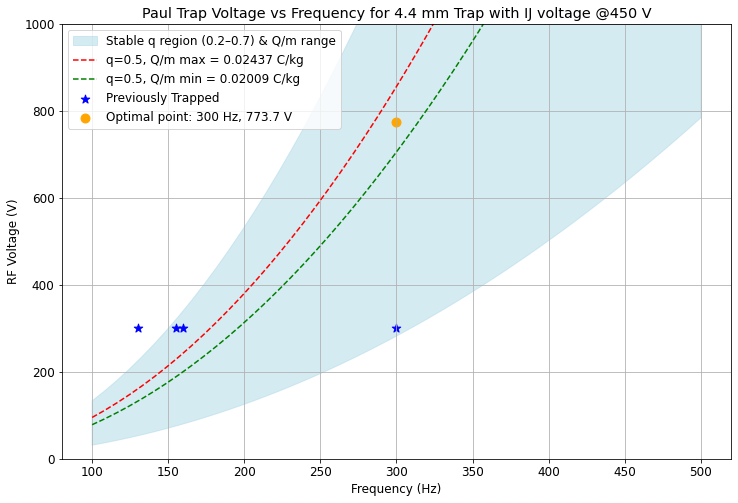

In [26]:

## Parameters 
r0 = 4.4e-3  # Trap radius (m)
f = np.linspace(100,500)  # Frequencies in Hz

## Droplet Q/m measured diameter range of 49-53 µm ethanol drops

Q_m_min = 0.020086749303979034 # C/kg
Q_m_max = 0.02436905126682231 # C/kg


## Stability parameter q 
q_low = 0.2
q_nom = 0.5
q_high = 0.7

## RF voltage calculation
def V_RF(Q_m, q, f):
    return (q * r0**2 * (2 * np.pi * f)**2) / (2 * Q_m)

## Voltages for full stability envelope
V_low = V_RF(Q_m_max, q_low, f)
V_high = V_RF(Q_m_min, q_high, f)

##  Voltages for nominal q lines
V_nom_min = V_RF(Q_m_min, q_nom, f)
V_nom_max = V_RF(Q_m_max, q_nom, f)

## Optimal operating point
f_opt = 300  # Hz
Q_m_opt = (Q_m_min + Q_m_max)/2  # midpoint Q/m
q_opt = 0.5
V_opt = V_RF(Q_m_opt, q_opt, f_opt)

plt.figure(figsize=(12,8))
plt.fill_between(f, V_low, V_high, color='lightblue', alpha=0.5, label='Stable q region (0.2–0.7) & Q/m range')
plt.plot(f, V_nom_min, 'r--', label='q=0.5, Q/m max = 0.02437 C/kg')
plt.plot(f, V_nom_max, 'g--', label='q=0.5, Q/m min = 0.02009 C/kg')


plt.scatter(PT_freq_list,PT_volts_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')

plt.scatter(f_opt, V_opt, color='orange', s=80, label=f'Optimal point: {f_opt} Hz, {V_opt:.1f} V')
plt.xlabel('Frequency (Hz)')
plt.ylabel('RF Voltage (V)')
plt.ylim((0,1000))
plt.title('Paul Trap Voltage vs Frequency for 4.4 mm Trap with IJ voltage @450 V')

plt.legend()
plt.rcParams.update({'font.size': 12})
plt.grid(True)
plt.show()


# Trap stability region for 1.2mm trap radius, given Inkjet voltage = 450 V

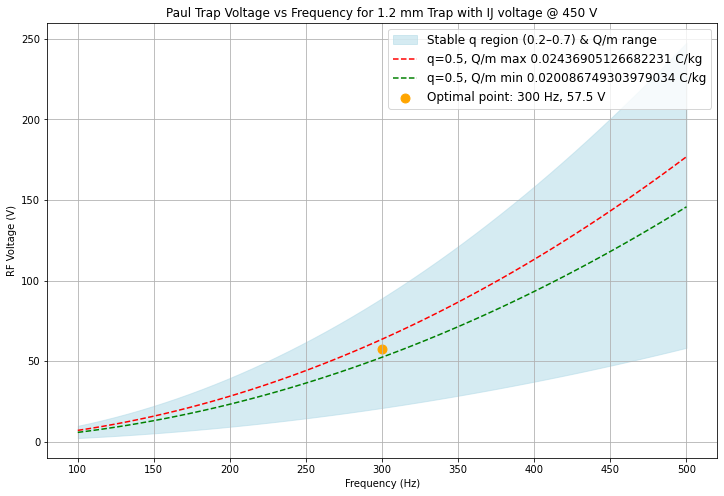

In [17]:

## Parameters 
r0 = 1.2e-3  # Trap radius (m)
f = np.linspace(100,500)  # Frequencies in Hz

## Droplet Q/m measured diameter range of 49-53 µm ethanol drops

Q_m_min = 0.020086749303979034 # C/kg
Q_m_max = 0.02436905126682231 # C/kg


## Stability parameter q 
q_low = 0.2
q_nom = 0.5
q_high = 0.7

## RF voltage calculations
def V_RF(Q_m, q, f):
    return (q * r0**2 * (2 * np.pi * f)**2) / (2 * Q_m)

## Voltages for full stability envelope
V_low = V_RF(Q_m_max, q_low, f)
V_high = V_RF(Q_m_min, q_high, f)

##  Voltages for nominal q lines
V_nom_min = V_RF(Q_m_min, q_nom, f)
V_nom_max = V_RF(Q_m_max, q_nom, f)

## Optimal operating point
f_opt = 300  # Hz
Q_m_opt = (Q_m_min + Q_m_max)/2  # midpoint Q/m
q_opt = 0.5
V_opt = V_RF(Q_m_opt, q_opt, f_opt)

plt.figure(figsize=(12,8))
plt.fill_between(f, V_low, V_high, color='lightblue', alpha=0.5, label='Stable q region (0.2–0.7) & Q/m range')
plt.plot(f, V_nom_min, 'r--', label='q=0.5, Q/m max 0.02436905126682231 C/kg')
plt.plot(f, V_nom_max, 'g--', label='q=0.5, Q/m min 0.020086749303979034 C/kg')


#plt.scatter(PT_volts_list,PT_freq_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')

plt.scatter(f_opt, V_opt, color='orange', s=80, label=f'Optimal point: {f_opt} Hz, {V_opt:.1f} V')
plt.xlabel('Frequency (Hz)')
plt.ylabel('RF Voltage (V)')
#plt.ylim((0,40))
plt.title('Paul Trap Voltage vs Frequency for 1.2 mm Trap with IJ voltage @ 450 V')

plt.rcParams.update({'font.size': 12})
plt.legend()
plt.grid(True)
plt.show()


# Radius Vs Freq given min and max Q/m at Inkjet voltage of 450 V

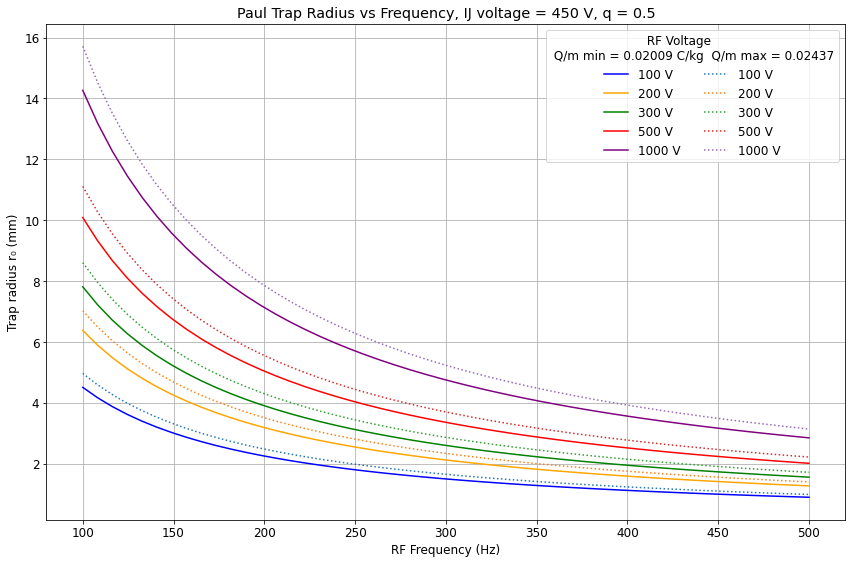

In [30]:
## Fixed parameters
Q_m_min = 0.020086749303979034 # C/kg 
q = 0.5     # Mathieu stability parameter (typical)
freq = np.linspace(100, 500)  # Hz

## RF voltages to compare
voltages = [100, 200, 300, 500, 1000]  # RF Drive voltage (aka voltage on the rods)
colors = ['blue','orange','green', 'red', 'purple'] 


## Trap radius formula is  r0 = sqrt( 2(Q/m)V / ( q (2πf)^2 ) )
def trap_radius(V, f):
    return np.sqrt((2 * Q_m_min * V) / (q * (2*np.pi*f)**2))

plt.figure(figsize=(12,8))

for i in range(0,5):
    V = voltages[i]
    r0 = trap_radius(V, freq)
    plt.plot(freq, r0*1e3, label=f"{V} V",color=colors[i])  # convert to mm


#second plots
Q_m_max = 0.02436905126682231 # C/kg 

# Trap radius formula is  r0 = sqrt( 2(Q/m)V / ( q (2πf)^2 ) )
def trap_radius(V, f):
    return np.sqrt((2 * Q_m_max * V) / (q * (2*np.pi*f)**2))

for V in voltages:
    r0 = trap_radius(V, freq)
    plt.plot(freq, r0*1e3, label=f"{V} V", alpha =1 , linestyle = 'dotted')  # convert to mm


plt.xlabel("RF Frequency (Hz)")
plt.ylabel("Trap radius r₀ (mm)")
plt.title("Paul Trap Radius vs Frequency, IJ voltage = 450 V, q = 0.5")
plt.grid(True)
plt.legend(title='                         RF Voltage \n Q/m min = 0.02009 C/kg  Q/m max = 0.02437', ncol=2)

plt.tight_layout()
plt.show()
plt_2.show()

# Paul Trap design map given min and max Q/m at Inkjet voltage = 450V

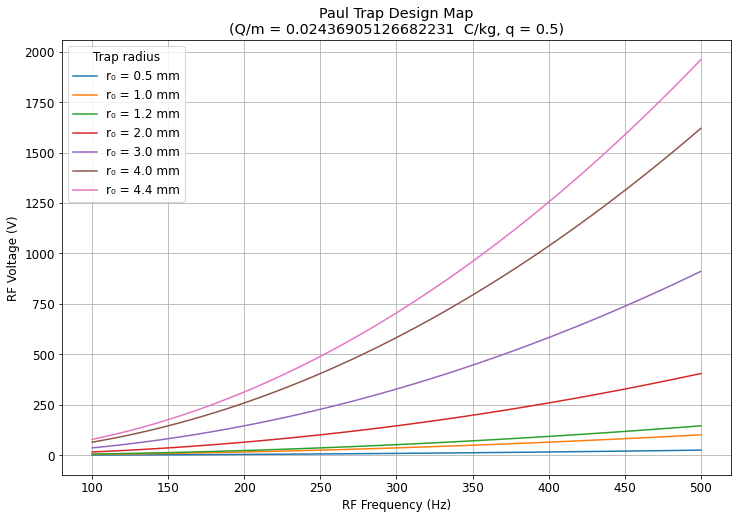

In [32]:

# Fixed parameters
Q_m_max = 0.02436905126682231  # C/kg 
q = 0.5             # Mathieu parameter (typical stable value)

# Frequency range
f = np.linspace(100, 500)  # Hz

plt.figure(figsize=(12,8))

# Trap radii to plot (in mm) to compare
radii_mm = [0.5, 1.0, 1.2, 2.0, 3.0, 4.0, 4.4]
colors = ['blue','orange','green', 'red', 'purple', 'brown', 'pink'] 

# Convert to meters
radii = [r*1e-3 for r in radii_mm]

# Voltage formula:
# V = q * r0^2 * (2πf)^2 / (2 * Q/m)

def V_RF(r0, f):
    return (q * r0**2 * (2*np.pi*f)**2) / (2 * Q_m_max)


for r0, rmm in zip(radii, radii_mm):
    V = V_RF(r0, f)
    plt.plot(f, V, label=f"r₀ = {rmm} mm")
    
#plt.figure(figsize=(12,8))
#plt.scatter(PT_freq_list,PT_volts_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')
plt.xlabel("RF Frequency (Hz)")
plt.ylabel("RF Voltage (V)")
plt.title("Paul Trap Design Map\n(Q/m = 0.02436905126682231  C/kg, q = 0.5)")
plt.grid(True)

plt.rcParams.update({'font.size': 12})
plt.legend(title="Trap radius")


#plt.tight_layout()
plt.show()


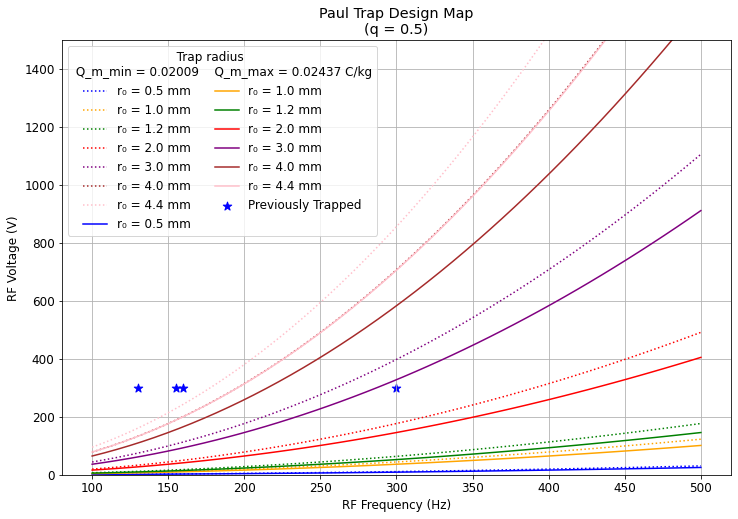

In [33]:

# Fixed parameters
Q_m_min = 0.020086749303979034 # C/kg 
Q_m_max = 0.02436905126682231 
q = 0.5             # Mathieu parameter (typical stable value)

# Frequency range
f = np.linspace(100, 500)  # Hz

plt.figure(figsize=(12,8))

# Trap radii to plot (in mm) to compare
radii_mm = [0.5, 1.0, 1.2, 2.0, 3.0, 4.0, 4.4]
colors = ['blue','orange','green', 'red', 'purple', 'brown', 'pink'] 

# Convert to meters
radii = [r*1e-3 for r in radii_mm]

# Voltage formula:
# V = q * r0^2 * (2πf)^2 / (2 * Q/m)

def V_RF(r0, f):
    return (q * r0**2 * (2*np.pi*f)**2) / (2 * Q_m_min)


i=0
for r0, rmm in zip(radii, radii_mm):
    V = V_RF(r0, f)
    plt.plot(f, V, label=f"r₀ = {rmm} mm", color=colors[i], linestyle = 'dotted')
    i=i+1


def V_RF(r0, f):
    return (q * r0**2 * (2*np.pi*f)**2) / (2 * Q_m_max)

i=0
for r0, rmm in zip(radii, radii_mm):
    V = V_RF(r0, f)
    plt.plot(f, V, label=f"r₀ = {rmm} mm", color=colors[i])
    i=i+1
    
#plt.figure(figsize=(12,8))
plt.scatter(PT_freq_list,PT_volts_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')
plt.xlabel("RF Frequency (Hz)")
plt.ylabel("RF Voltage (V)")
plt.ylim(0,1500)
plt.title("Paul Trap Design Map\n(q = 0.5)")
plt.grid(True)

plt.rcParams.update({'font.size': 12})
plt.legend(title='                           Trap radius \n Q_m_min = 0.02009    Q_m_max = 0.02437 C/kg',  ncol = 2)


#plt.tight_layout()
plt.show()


# Trying to find trap depth by using the pseudopotential evaluated at the edge of the stability region when r=r_o

The pseudopontential equation is $$ U_{depth} = \frac{q^2 * V_{rf}^2}{4*m*\Omega^2*r_o^2} $$ where q is charge, V_rf is the Paul trap voltage, m is mass, omega is the paul trap frequency , and r_o is the trap radius 

I found this equation by finding the effective potential energy of charge q in an RF field which is
$$ V_{eff}(r) = \frac{q^2}{4*m*\Omega^2} * \vec{E}$$ 

**Eq 4 of this paper https://www.sciencedirect.com/science/article/pii/S1387380610003465 **

I approximated the electric field magnitude near r as $$ E(r) = \frac{V_{RF}^2*r^2}{r_0^4} $$ and plugged it back into the above to obtain $$ V_{eff}(r) = \frac{q^2}{4*m*\Omega^2} * \frac{V_{RF}^2*r^2}{r_0^4}$$ 

but since we want to find the trap depth, the pseudopotential, $$ U_{depth}= V_{eff}(r=r_o) $$, is at the eletrode radius so we can let r = r_o, reducing the above to $$ U_{depth} = \frac{q^2}{4*m*\Omega^2} * \frac{V_{RF}^2}{r_0^2}$$ 


In [24]:
# ##pseudopontential equation is U_depth = (q^2 * V_rf^2)/(4*m*omega^2*r_o^2) 

# def trap_depth(q, m, Vrf, freq, r0):  ## q is in coulombs, V is in volts (aka J/C), mass is in kg, omega is in Hz, and r-o is in meters. 
#     #So the trap depth should be in joules
    
#     r_drop = 5e-5
#     Omega = 2*math.pi*freq
#     epsilon = 8.854*10**-12 ##Epsilon is the permitivity of free space with units of F/m
#     m = 4/3*math*pi*r_drop**3
#     q = Vrf*4*math.pi*epsilon*r_drop
#     U = (q**2 * Vrf**2) / (4 * m * Omega**2 * r0**2)
#     r_drop = 5e-5

#     return U   # Joules

# U = trap_depth(q=Vrf*4*math.pi*epsilon*r_drop, m, 300, 300, 4.4e-3)

# print(U)

# ##but if we let m = 4/3*pi*r^3*rho (the way i found the mass above)

In [44]:

# epsilon = 8.854e-12

# def droplet_charge(radius, Vd):
#     return 4*np.pi*epsilon*radius*Vd

# def trap_depth(q, m, Vrf, f, r0):

#     Omega = 2*np.pi*f
    
#     U = (q**2 * Vrf**2) / (4 * m * Omega**2 * r0**2)

#     return U

# def mathieu_q(q, m, Vrf, f, r0):

#     Omega = 2*np.pi*f

#     return (2*q*Vrf)/(m*r0**2*Omega**2)

In [45]:
# U = trap_depth(1.1515683800921986e-12, 4.0211393222670816e-11 , 300, 300, 4.4e-3) ##mass and charge were calculated using a drop diameter of 46 um and a voltage of 450V

# print ('Trap depth',U, 'Joules')


In [47]:

# constants
epsilon = 8.854e-12     # vacuum permittivity (F/m)
rho_ethanol = 789       # ethanol density (kg/m^3)

# trap parameters 
Vrf = 300               # RF voltage amplitude (V)
freq = 300              # RF frequency (Hz)
r0 = 4.4e-3             # trap radius (m)

# droplet potential relative to ground
Vd = 450                 # change if needed

# droplet diameter range
d_min = 49e-6
d_max = 53e-6


# derived quantities
Omega = 2*np.pi*freq

def droplet_mass(radius):
    """Mass of ethanol droplet"""
    return (4/3)*np.pi*radius**3*rho_ethanol

def droplet_charge(radius):
    """Charge assuming conducting sphere"""
    return 4*np.pi*epsilon*radius*Vd

def trap_depth(q, m):
    """Pseudopotential trap depth (J)""" ##pseudopontential equation is U_depth = (q^2 * V_rf^2)/(4*m*omega^2*r_o^2) 
    return (q**2 * Vrf**2) / (4 * m * Omega**2 * r0**2)

def mathieu_q(q, m):
    """Mathieu stability parameter, q"""
    return (2*q*Vrf)/(m*r0**2*Omega**2)


# calculate for droplet range
for d in [d_min, d_max]:

    r = d/2
    m = droplet_mass(r)
    q = droplet_charge(r)
    Charge_to_mass_ratio = q/m


    U = trap_depth(q, m)
    qM = mathieu_q(q, m)

    print("Droplet diameter:", d*1e6, "um")
    print("Mass:", m, "kg")
    print("Mass:", m*1e12, "ng")
    print("Charge:", q, "C")
    print('Charge to mass ratio',Charge_to_mass_ratio, 'C/kg')
    print("Mathieu q:", qM)
    print("Trap depth:", U, "J")
    print("Trap depth:", U/1.602e-19, "eV")
    print()

Droplet diameter: 49.0 um
Mass: 4.8603088284437386e-11 kg
Mass: 48.60308828443738 ng
Charge: 1.2266706657503855e-12 C
Charge to mass ratio 0.025238533374085263 C/kg
Mathieu q: 0.22014446236733504
Trap depth: 1.0126678283002484e-11 J
Trap depth: 63212723.36455982 eV

Droplet diameter: 53.0 um
Mass: 6.150398196773612e-11 kg
Mass: 61.503981967736124 ng
Charge: 1.3268070466279681e-12 C
Charge to mass ratio 0.021572701541893453 C/kg
Mathieu q: 0.1881690473990642
Trap depth: 9.362400676738145e-12 J
Trap depth: 58441951.78987606 eV



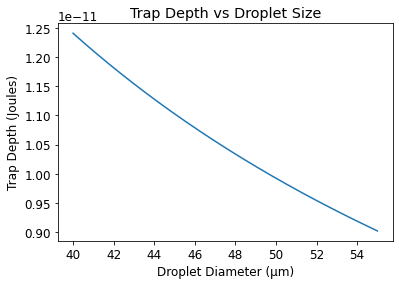

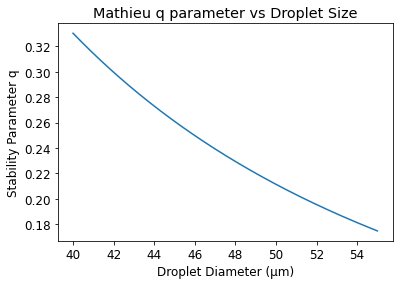

In [43]:
## Generate trap depth vs droplet size and Mathieu q vs droplet size plots
# Constants
epsilon = 8.854e-12        # vacuum permittivity (F/m)
rho_ethanol = 789       # ethanol density (kg/m^3)
e_charge = 1.602e-19    # elementary charge (C)

# Trap parameters (user-editable core parameters)
Vrf = 300        # RF voltage amplitude (V)
freq = 300       # RF frequency (Hz)
r0 = 4.4e-3      # trap radius (m)

# Droplet potential assumption for conducting sphere model
Vd = 450          # droplet potential relative to ground (V)

Omega = 2*np.pi*freq

# Diameter sweep (meters)
diameters = np.linspace(40e-6, 55e-6, 200)
radii = diameters / 2

# Functions
def droplet_mass(r):
    return (4/3) * np.pi * r**3 * rho_ethanol

def droplet_charge(r):
    return 4 * np.pi * epsilon * r * Vd

def trap_depth(q, m):
    return (q**2 * Vrf**2) / (4 * m * Omega**2 * r0**2)

def mathieu_q(q, m):
    return (2*q*Vrf)/(m*r0**2*Omega**2)

# Compute values
trap_depths = []
mathieu_vals = []

for r in radii:
    m = droplet_mass(r)
    q = droplet_charge(r)
    #trap_depths.append(trap_depth(q, m) / e_charge)  # convert to eV
    trap_depths.append(trap_depth(q, m))  # to keep in Joules
    mathieu_vals.append(mathieu_q(q, m))

diam_um = diameters * 1e6

# Plot 1: Trap depth vs droplet size
plt.figure()
plt.plot(diam_um, trap_depths)
plt.xlabel("Droplet Diameter (µm)")
plt.ylabel("Trap Depth (Joules)")
plt.title("Trap Depth vs Droplet Size")
plt.show()

# Plot 2: Mathieu q vs droplet size
plt.figure()
plt.plot(diam_um, mathieu_vals)
plt.xlabel("Droplet Diameter (µm)")
plt.ylabel("Stability Parameter q")
plt.title("Mathieu q parameter vs Droplet Size")
plt.show()

# What does this imply? 
1) From this we see that the smaller drops are trapped stronger since depth is proportional to q^2/m
2) The mathieu stability parameter, q, seems to decrease as drops get bigger
3) So as the drops evaporate and shrink, the trap depth increases as well as the Mathieu stability parameter, making a more confining trap

In [ ]:
## from this we see that the smaller drops are trapped stronger since trap depth is proportional to q^2/m
##Trap depth is inversly proportional to droplet radius, so the smaller the ...actually idk
##The mathieu stability parameter, q, seems to decrease as drops get bigger
##So as the drops evaporate and shrink, the trap depth increases as well as the Mathieu stability parameter, making a more confining trap

Below is the same as above but using the electrospray voltage rather than the inkjet voltage

In [30]:

# constants

epsilon = 8.854e-12        # vacuum permittivity (F/m)
rho_ethanol = 789       # ethanol density (kg/m^3)


# trap parameters 


Vrf = 300               # RF voltage amplitude (V)
freq = 300              # RF frequency (Hz)
r0 = 4.4e-3             # trap radius (m)

# droplet potential relative to ground
Vd = 3000                 # change if needed

# droplet diameter range
d_min = 46e-6
d_max = 53e-6


# derived quantities


Omega = 2*np.pi*freq

def droplet_mass(radius):
    """Mass of ethanol droplet"""
    return (4/3)*np.pi*radius**3*rho_ethanol

def droplet_charge(radius):
    """Charge assuming conducting sphere"""
    return 4*np.pi*epsilon*radius*Vd

def trap_depth(q, m):
    """Pseudopotential trap depth (J)"""
    return (q**2 * Vrf**2) / (4 * m * Omega**2 * r0**2)

def mathieu_q(q, m):
    """Mathieu stability parameter"""
    return (2*q*Vrf)/(m*r0**2*Omega**2)


# calculate for droplet range


for d in [d_min, d_max]:

    r = d/2
    m = droplet_mass(r)
    q = droplet_charge(r)
    Charge_to_mass_ratio = q/m


    U = trap_depth(q, m)
    qM = mathieu_q(q, m)

    print("Droplet diameter:", d*1e6, "um")
    print("Mass:", m, "kg")
    print("Mass:", m*1e12, "ng")
    print("Charge:", q, "C")
    print('Charge to mass ratio',Charge_to_mass_ratio, 'C/kg')
    print("Mathieu q:", qM)
    print("Trap depth:", U, "J")
    print("Trap depth:", U/1.602e-19, "eV")
    print()

Droplet diameter: 46.0 um
Mass: 4.0211393222670816e-11 kg
Mass: 40.211393222670814 ng
Charge: 7.677122533947991e-12 C
Charge to mass ratio 0.19091908831499277 C/kg
Mathieu q: 1.665301997933117
Trap depth: 4.794272810310354e-10 J
Trap depth: 2992679656.87288 eV

Droplet diameter: 53.0 um
Mass: 6.150398196773612e-11 kg
Mass: 61.503981967736124 ng
Charge: 8.845380310853121e-12 C
Charge to mass ratio 0.1438180102792897 C/kg
Mathieu q: 1.2544603159937615
Trap depth: 4.1610669674391757e-10 J
Trap depth: 2597420079.5500474 eV



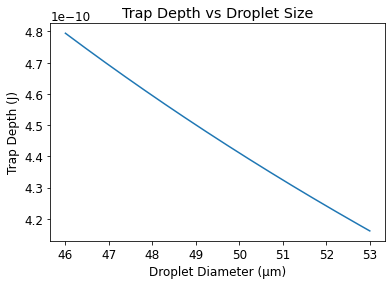

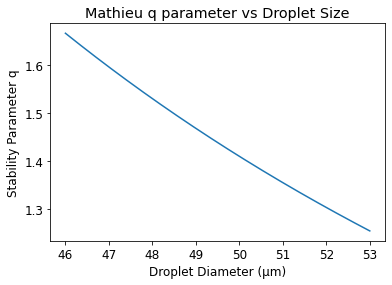

In [35]:
## Generate trap depth vs droplet size and Mathieu q vs droplet size plots
# Constants
epsilon = 8.854e-12        # vacuum permittivity (F/m)
rho_ethanol = 789       # ethanol density (kg/m^3)
e_charge = 1.602e-19    # elementary charge (C)

# Trap parameters (user-editable core parameters)
Vrf = 300        # RF voltage amplitude (V)
freq = 300       # RF frequency (Hz)
r0 = 4.4e-3      # trap radius (m)

# Droplet potential assumption for conducting sphere model
Vd = 3000          # droplet potential relative to ground (V)

Omega = 2*np.pi*freq

# Diameter sweep (meters)
diameters = np.linspace(46e-6, 53e-6, 200)
radii = diameters / 2

# Functions
def droplet_mass(r):
    return (4/3) * np.pi * r**3 * rho_ethanol

def droplet_charge(r):
    return 4 * np.pi * epsilon * r * Vd

def trap_depth(q, m):
    return (q**2 * Vrf**2) / (4 * m * Omega**2 * r0**2)

def mathieu_q(q, m):
    return (2*q*Vrf)/(m*r0**2*Omega**2)

# Compute values
trap_depths = []
mathieu_vals = []

for r in radii:
    m = droplet_mass(r)
    q = droplet_charge(r)
    trap_depths.append(trap_depth(q, m))  # convert to eV
    mathieu_vals.append(mathieu_q(q, m))

diam_um = diameters * 1e6

# Plot 1: Trap depth vs droplet size
plt.figure()
plt.plot(diam_um, trap_depths)
plt.xlabel("Droplet Diameter (µm)")
plt.ylabel("Trap Depth (J)")
plt.title("Trap Depth vs Droplet Size")
plt.show()

# Plot 2: Mathieu q vs droplet size
plt.figure()
plt.plot(diam_um, mathieu_vals)
plt.xlabel("Droplet Diameter (µm)")
plt.ylabel("Stability Parameter q")
plt.title("Mathieu q parameter vs Droplet Size")
plt.show()